## Exploratory Data Analysis (EDA) for News Dataset
1. Setup

### Assuming your dataset is loaded as:

In [158]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Administrator\Desktop\FNSPID-KIFYA-week1\data\raw_analyst_ratings.csv")
# Convert to datetime (handles timezone, no timezone, and mixed)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract ONLY the date (YYYY-MM-DD)
df['date'] = df['date'].dt.date

df.head(20)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22,A
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22,A
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22,A
7,7,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22,A
8,8,Wells Fargo Maintains Overweight on Agilent Te...,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,2020-05-22,A
9,9,10 Biggest Price Target Changes For Friday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-05-22,A


## 2. Descriptive Statistics
2.1 Headline Length Analysis

Goal: Understand how long the headlines typically are, identify long/short outliers, and see if different publishers write differently.

Steps

Compute number of characters per headline.

Compute number of words per headline.

Generate descriptive statistics.

In [159]:
df['headline_length_char'] = df['headline'].astype(str).apply(len)
df['headline_length_words'] = df['headline'].astype(str).apply(lambda x: len(x.split()))

df[['headline_length_char', 'headline_length_words']].describe()


,headline_length_char,headline_length_words
count,1.407328e+06,1.407328e+06
mean,7.312051e+01,1.141671e+01
std,4.073531e+01,6.352997e+00
min,3.000000e+00,1.000000e+00
25%,4.700000e+01,7.000000e+00
50%,6.400000e+01,1.000000e+01
75%,8.700000e+01,1.300000e+01
max,5.120000e+02,7.700000e+01


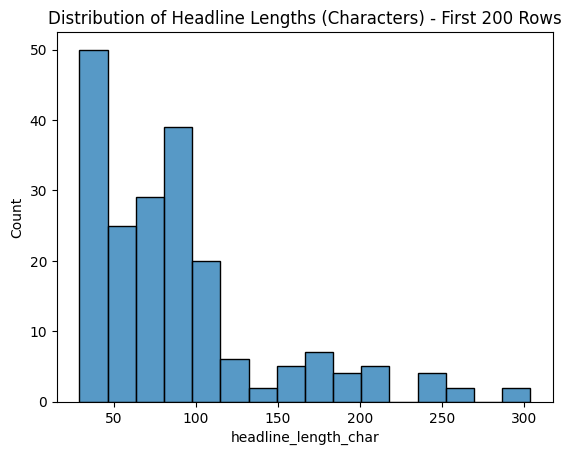

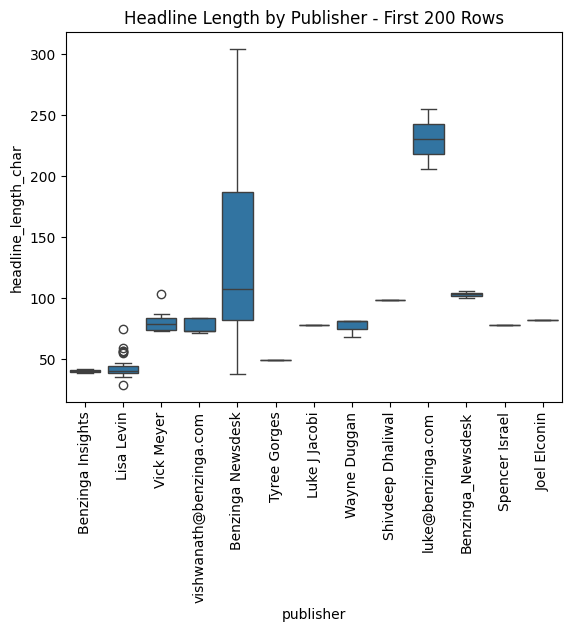

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['headline_length_char'].iloc[:200])
plt.title("Distribution of Headline Lengths (Characters) - First 200 Rows")
plt.show()


sns.boxplot(data=df.iloc[:100], x='publisher', y='headline_length_char')
plt.title("Headline Length by Publisher - First 200 Rows")
plt.xticks(rotation=90)
plt.show()


What you can see from the bars:

Most headlines are short: The tallest bar is on the far left, around 50 characters. This means the most common headline length is about 50 characters.
Headlines get less common as they get longer: As you move to the right (longer headlines), the bars get shorter. There are fewer headlines that are 100 characters, even fewer that are 150, and so on.
Very long headlines are rare: The bars on the far right (like 250 or 300 characters) are very small. This means very few headlines are extremely long.

## 3. Publisher Activity Analysis
3.1 Count Articles Per Publisher

This identifies:

Most active publishers.

Outliers (publishers with very few articles).

Potential bias in dataset representation.

In [161]:
publisher_counts = df['publisher'].value_counts()
publisher_counts


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
MoneyGeek                 1
muathe                    1
Robert Morris             1
LeftCoastHedgie           1
Jeremie Capron            1
Name: count, Length: 1034, dtype: int64

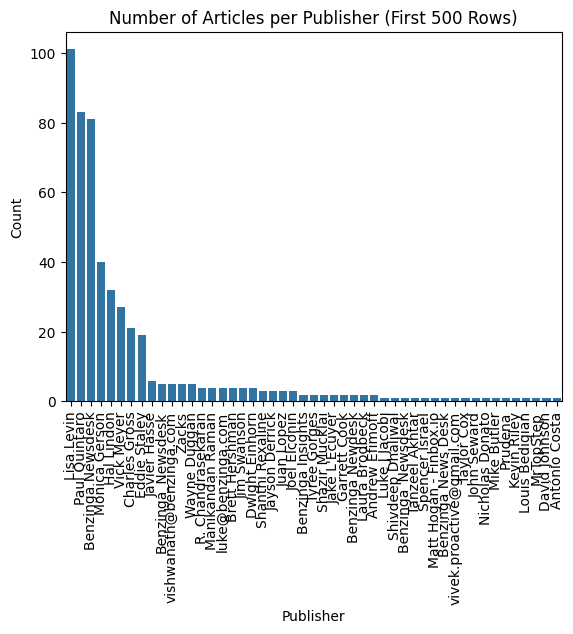

In [162]:
# Use only the first 200 rows
subset = df.iloc[:500]

# Count publishers in these 200 rows
publisher_counts = subset['publisher'].value_counts()

# Plot
sns.barplot(x=publisher_counts.index, y=publisher_counts.values)
plt.xticks(rotation=90)
plt.title("Number of Articles per Publisher (First 500 Rows)")
plt.ylabel("Count")
plt.xlabel("Publisher")
plt.show()


Actually, looking closely, it seems the chart might be showing a total 500 samples. But the main point is clear: Paula Levin, Lisa Levin, and Benzinga Newsdesk are by far the most active.

Everyone else combined wrote only a tiny fraction of the total. So, the top 3 are the real workhorses here! 


## 4.2 Daily Article Frequency

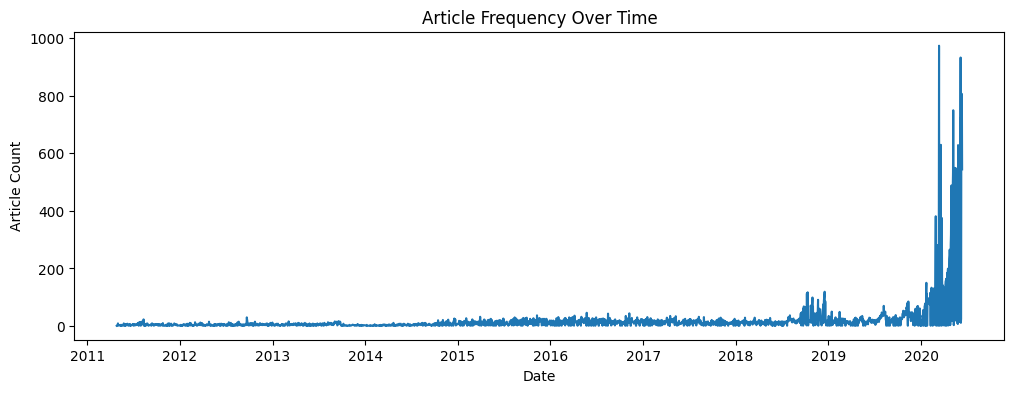

In [163]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
daily_counts = df.groupby(df['date'].dt.date).size()

daily_counts.plot(kind='line', figsize=(12,4))
plt.title("Article Frequency Over Time")
plt.ylabel("Article Count")
plt.xlabel("Date")
plt.show()


🔍 What you can see:
From 2011 to 2019: Very Quiet
The line stays very low, mostly near zero.
This means not many articles were being published each day during these years. Maybe just 1 or 2 per day, or even none for days at a time.
In 2020: Everything Changes!
Around mid-2020, the line suddenly jumps up.
It goes from almost nothing to hundreds of articles per day!
There are even some days where the count spikes to nearly 1,000 articles.
Late 2020 to 2021: High Activity
After the big jump in 2020, the number of daily articles stays high, with lots of peaks and valleys.
This means publishing became much more frequent — maybe several hundred articles every day.

## 4.3 Trends Per Publisher

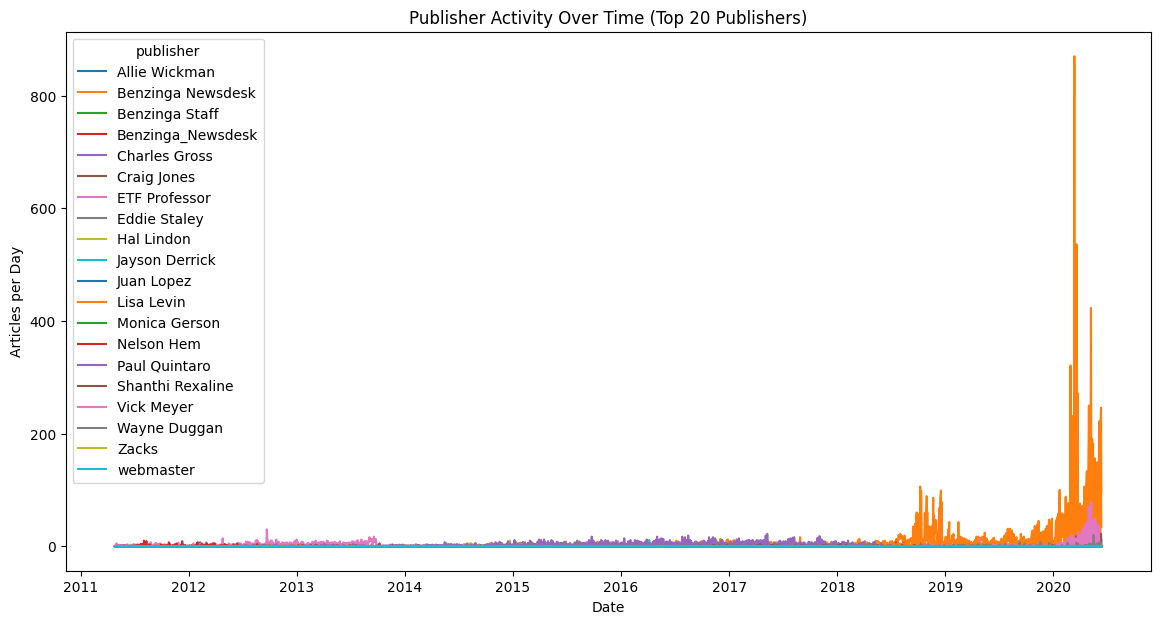

In [164]:


# 1. Find the top 20 publishers by total articles
top20_publishers = df['publisher'].value_counts().head(20).index

# 2. Filter dataframe to include only top 20 publishers
df_top20 = df[df['publisher'].isin(top20_publishers)]

# 3. Group by date and publisher
publisher_daily = df_top20.groupby([df_top20['date'].dt.date, 'publisher']).size().unstack(fill_value=0)

# 4. Plot
publisher_daily.plot(figsize=(14,7))
plt.title("Publisher Activity Over Time (Top 20 Publishers)")
plt.ylabel("Articles per Day")
plt.xlabel("Date")
plt.show()


## 5. Stock Field Analysis

If your dataset includes a stock price or stock ticker associated with each article, consider:

5.1 Article Count per Stock

In [165]:
df['stock'].value_counts()


stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
        ... 
DWM        1
DWAT       1
DVP        1
DXJS       1
DXJR       1
Name: count, Length: 6204, dtype: int64

5.2 Mean Headline Length by Stock

In [166]:
df.groupby('stock')['headline_length_words'].mean()


stock
A       10.963712
AA      10.253742
AAC     10.648148
AADR     8.000000
AAL     17.521739
          ...    
ZTR     12.315789
ZTS     12.085072
ZU       8.956522
ZUMZ     9.740314
ZX      10.283582
Name: headline_length_words, Length: 6204, dtype: float64

## Time-Series of Stock Mentions

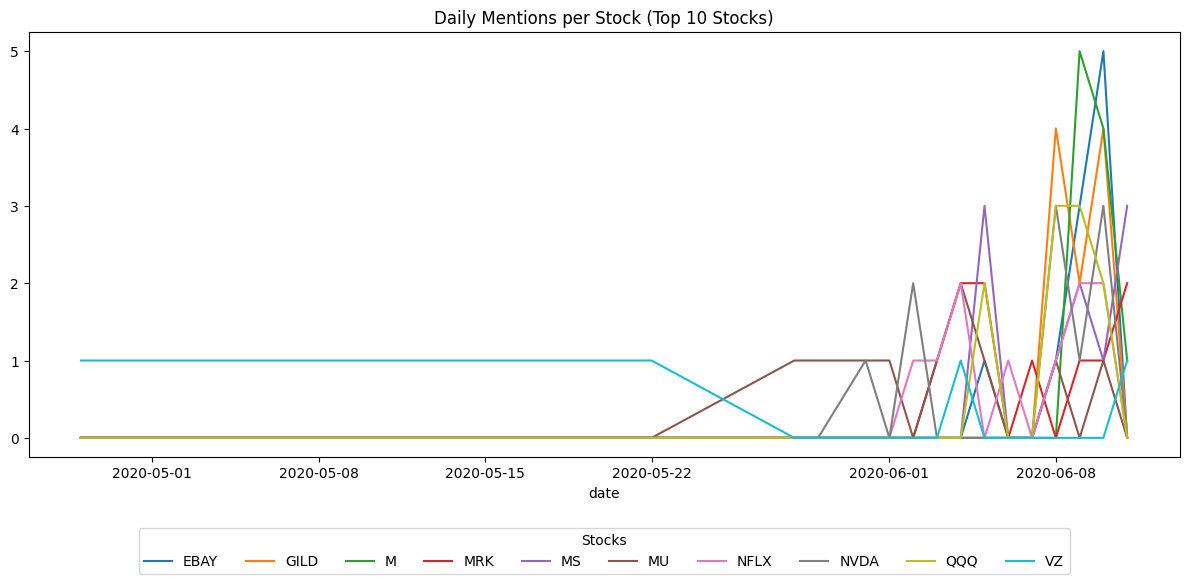

In [167]:
# 1. Get top 500 stocks by number of articles
top_500_stocks = df['stock'].value_counts().head(10).index

# 2. Filter the dataframe to only those stocks
df_top500 = df[df['stock'].isin(top_500_stocks)]

# 3. Group and plot
stock_daily = df_top500.groupby([df_top500['date'].dt.date, 'stock']).size().unstack(fill_value=0)

ax = stock_daily.plot(figsize=(12,6))
plt.title("Daily Mentions per Stock (Top 10 Stocks)")

# 🔹 Make legend horizontal
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=10,     # More columns (500 stocks is a lot!)
    title="Stocks"
)

plt.tight_layout()
plt.show()


## Text Analysis(Topic Modeling)
NLP Analysis: Keyword Extraction, Phrase Extraction, and Topic Insights

In [168]:
import pandas as pd
import re

# Simple stopwords list (common English stopwords)
basic_stop_words = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", 
    "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 
    'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 
    'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 
    'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 
    'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 
    'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 
    'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 
    'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 
    'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 
    'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 
    'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 
    'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', 
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', 
    "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

def clean_text_simple(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()  # Simple whitespace tokenization
    tokens = [w for w in tokens if w not in basic_stop_words and len(w) > 2]
    return " ".join(tokens)

df['clean_headline'] = df['headline'].astype(str).apply(clean_text_simple)

### 3. Keyword Extraction (Unigrams)
3.1 Most Frequent Words

This identifies the most common topics or sentiment drivers.

In [169]:
from collections import Counter

all_words = " ".join(df['clean_headline']).split()

word_freq = Counter(all_words)
word_freq.most_common(30)


[('stocks', 161868),
 ('est', 140606),
 ('eps', 128929),
 ('shares', 114209),
 ('reports', 108707),
 ('update', 91680),
 ('market', 90880),
 ('earnings', 87185),
 ('sales', 79526),
 ('top', 78678),
 ('week', 67669),
 ('announces', 66529),
 ('price', 64232),
 ('buy', 64060),
 ('downgrades', 61942),
 ('trading', 61158),
 ('benzingas', 57985),
 ('raises', 57798),
 ('upgrades', 56804),
 ('target', 54620),
 ('maintains', 52961),
 ('higher', 48163),
 ('new', 48061),
 ('session', 45326),
 ('inc', 44917),
 ('says', 43126),
 ('moving', 42264),
 ('premarket', 39322),
 ('stock', 39232),
 ('sees', 37984)]

### 4 Phrase Extraction (Bigrams & Trigrams)
4.1 Extract Frequent Bigrams and Trigrams

In [170]:
from nltk.util import ngrams

def get_ngrams(text_series, n=2, top=20):
    all_words = " ".join(text_series).split()
    n_grams = ngrams(all_words, n)
    freq = Counter(n_grams)
    return freq.most_common(top)

bigrams = get_ngrams(df['clean_headline'], n=2, top=30)
trigrams = get_ngrams(df['clean_headline'], n=3, top=30)

bigrams, trigrams


([(('eps', 'est'), 61274),
  (('reports', 'eps'), 51576),
  (('price', 'target'), 47266),
  (('benzingas', 'top'), 44258),
  (('stocks', 'moving'), 40060),
  (('market', 'update'), 33185),
  (('earnings', 'scheduled'), 32054),
  (('initiates', 'coverage'), 28983),
  (('sales', 'est'), 27203),
  (('shares', 'several'), 24078),
  (('companies', 'trading'), 23159),
  (('trading', 'higher'), 22937),
  (('adj', 'eps'), 21710),
  (('premarket', 'session'), 21670),
  (('top', 'upgrades'), 21112),
  (('trading', 'lower'), 20096),
  (('stocks', 'hit'), 20016),
  (('hit', 'week'), 19968),
  (('new', 'week'), 19288),
  (('option', 'alert'), 18226),
  (('est', 'sales'), 18165),
  (('week', 'highs'), 18017),
  (('biggest', 'movers'), 17795),
  (('stocks', 'set'), 16815),
  (('set', 'new'), 16801),
  (('revenue', 'est'), 16467),
  (('est', 'revenue'), 15550),
  (('morgan', 'stanley'), 15379),
  (('raises', 'price'), 15366),
  (('upgrades', 'downgrades'), 14822)],
 [(('reports', 'eps', 'est'), 35560)

In [171]:
def kwic_search(df, keyword, window=5):
    results = []
    for text in df['headline']:
        words = text.split()
        for i, w in enumerate(words):
            if keyword.lower() in w.lower():
                start = max(i - window, 0)
                end = min(i + window + 1, len(words))
                results.append(" ".join(words[start:end]))
    return results

kwic_search(df, "price")[:100]


['Neutral on Agilent Technologies, Raises Price Target to $88',
 'Hold on Agilent Technologies, Lowers Price Target to $85',
 'Neutral on Agilent Technologies, Raises Price Target to $87',
 'Overweight on Agilent Technologies, Raises Price Target to $95',
 '10 Biggest Price Target Changes For Friday',
 'Outperform on Agilent Technologies, Raises Price Target to $95',
 'their economies and as oil prices gain for the session.',
 'Neutral on Agilent Technologies, Lowers Price Target to $84',
 'Hold on Agilent Technologies, Lowers Price Target to $73',
 'Overweight on Agilent Technologies, Lowers Price Target to $82',
 'Equal-Weight on Agilent Technologies, Lowers Price Target to $76',
 'Neutral on Agilent Technologies, Lowers Price Target to $75',
 'Technologies to Hold, Announces $85 Price Target',
 'Neutral on Agilent Technologies, Raises Price Target to $90',
 'any news to justify the price action.',
 'with Overweight Rating, Announces $100 Price Target',
 'with Neutral Rating, Announc

In [172]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df['clean_headline'])

feature_names = tfidf.get_feature_names_out()
feature_names


array(['announces', 'bank', 'benzingas', 'benzingas top', 'biggest',
       'buy', 'companies', 'coverage', 'downgrades', 'earnings',
       'earnings scheduled', 'energy', 'eps', 'eps est', 'est',
       'estimate', 'higher', 'inc', 'initiates', 'lower', 'lowers',
       'maintains', 'market', 'market update', 'midday', 'moving',
       'neutral', 'new', 'premarket', 'price', 'price target', 'raises',
       'reports', 'reports eps', 'sales', 'says', 'scheduled', 'sees',
       'session', 'share', 'shares', 'stock', 'stocks', 'stocks moving',
       'target', 'top', 'trading', 'update', 'upgrades', 'week'],
      dtype=object)

### Topic Modeling (LDA)

In [173]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Use only the first 1000 rows
subset_df = df['clean_headline'].iloc[:10000]

# Create document-term matrix
cv = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = cv.fit_transform(subset_df)

# Fit LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

# Print top 10 words for each topic
for i, topic in enumerate(lda.components_):
    print(f"Topic {i+1}:")
    print([cv.get_feature_names_out()[index] for index in topic.argsort()[-10:]])
    print()


Topic 1:
['companies', 'markets', 'alcoa', 'lower', 'update', 'stock', 'higher', 'trading', 'market', 'shares']

Topic 2:
['yesterday', 'biggest', 'scheduled', 'watch', 'premarket', 'moving', 'session', 'earnings', 'week', 'stocks']

Topic 3:
['alert', 'option', 'airlines', 'earnings', 'atlas', 'aluminum', 'says', 'american', 'air', 'alcoa']

Topic 4:
['sees', 'adj', 'abbvie', 'advance', 'parts', 'auto', 'sales', 'reports', 'eps', 'est']

Topic 5:
['agilent', 'raises', 'alcoa', 'announces', 'maintains', 'upgrades', 'downgrades', 'price', 'target', 'buy']



## Time Series Analysis of News Publication Frequency

In [174]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['publication_date'] = df['date'].dt.date
df['publication_time'] = df['date'].dt.time
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.to_period('M')


In [175]:
rolling_mean = daily_counts.rolling(window=7).mean()
rolling_std = daily_counts.rolling(window=7).std()

spike_threshold = rolling_mean + 2 * rolling_std
spikes = daily_counts[daily_counts > spike_threshold]
spikes


date
2011-05-25      9
2011-07-19     10
2011-11-07      4
2011-12-10      9
2012-03-01     13
2012-04-16      6
2012-04-25     15
2012-05-16      7
2012-07-12     13
2012-09-21     30
2012-11-12     10
2012-12-06      8
2013-10-07      8
2013-10-31      4
2013-12-02      7
2014-01-21      3
2014-03-03      4
2014-03-12      5
2014-04-22     11
2015-01-06     18
2015-03-30     32
2015-07-24     15
2016-04-05     36
2016-08-15     43
2017-06-05     17
2017-08-28     31
2018-06-29     16
2018-10-23     71
2019-08-07     70
2020-03-12    973
2020-03-19    629
dtype: int64

In [176]:
weekday_counts = df['day_of_week'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

weekday_counts


day_of_week
Monday       10322
Tuesday      11002
Wednesday    11891
Thursday     12688
Friday        9381
Saturday       267
Sunday         436
Name: count, dtype: int64

Most news is released Monday–Thursday (expected).

Friday afternoon news often contains negative disclosures.

Weekend coverage = long-form or investigative reporting.

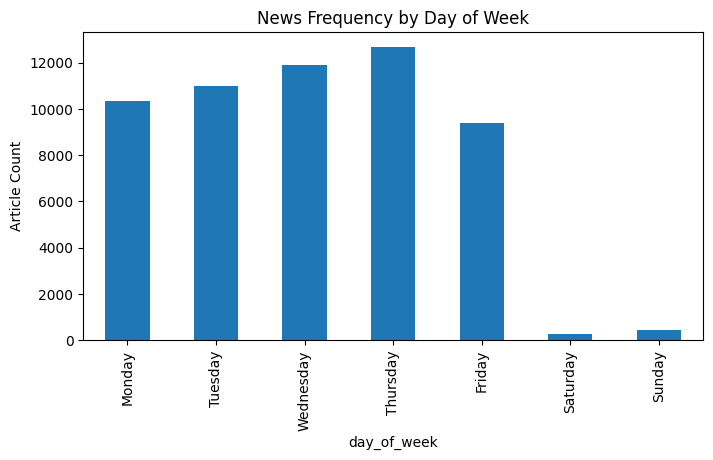

In [177]:
weekday_counts.plot(kind='bar', figsize=(8,4))
plt.title("News Frequency by Day of Week")
plt.ylabel("Article Count")
plt.show()


In [178]:
spike_day = spikes.index[0]

df[df['publication_date'] == spike_day]['headline'].tolist()
keywords_on_spike = " ".join(df[df['publication_date'] == spike_day]['clean_headline']).split()
Counter(keywords_on_spike).most_common(20)


[('california', 4),
 ('muni', 4),
 ('bonds', 4),
 ('reward', 4),
 ('worth', 4),
 ('risk', 4),
 ('part', 4),
 ('etf', 3),
 ('benzingas', 2),
 ('top', 2),
 ('may', 2),
 ('gainers', 1),
 ('agq', 1),
 ('erx', 1),
 ('bdd', 1),
 ('tna', 1),
 ('decliners', 1),
 ('zsl', 1),
 ('tvix', 1),
 ('ery', 1)]

## 1. Publisher Contribution Analysis

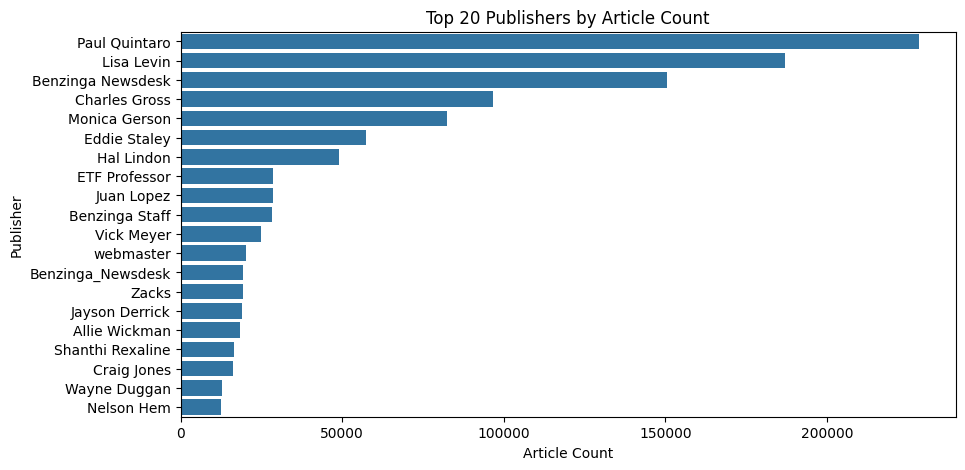

In [179]:
publisher_counts = df['publisher'].value_counts()
import seaborn as sns
import matplotlib.pyplot as plt

top_publishers = publisher_counts.head(20)

plt.figure(figsize=(10,5))
sns.barplot(x=top_publishers.values, y=top_publishers.index)
plt.title("Top 20 Publishers by Article Count")
plt.xlabel("Article Count")
plt.ylabel("Publisher")
plt.show()


### 2. Type of News per Publisher (Content Style Differences)

different publishers tend to report different types of events (e.g., earnings, price targets, regulatory events, mergers, lawsuits).

2.1 Create Keyword Categories

Define keyword groups for classification:

In [180]:
import re

def categorize_news(text):
    text = text.lower()
    if any(k in text for k in ["price target", "upgrade", "downgrade", "rating"]):
        return "Analyst/Ratings"
    if any(k in text for k in ["earnings", "quarter", "revenue", "profit"]):
        return "Earnings/Financials"
    if any(k in text for k in ["fda", "approval", "clinical", "trial"]):
        return "Regulatory/Approval"
    if any(k in text for k in ["merger", "acquisition", "deal", "buyout"]):
        return "Mergers/Acquisitions"
    if any(k in text for k in ["lawsuit", "investigation", "sec"]):
        return "Legal/Compliance"
    return "Other"
    
df['news_type'] = df['headline'].astype(str).apply(categorize_news)


In [181]:
publisher_news_type = df.groupby(['publisher', 'news_type']).size().unstack(fill_value=0)
publisher_news_type.head()


news_type,Analyst/Ratings,Earnings/Financials,Legal/Compliance,Mergers/Acquisitions,Other,Regulatory/Approval
publisher,,,,,,
47ertrends,0,0,0,0,18,0
AARP,0,0,0,0,7,0
ABNNewswire,1,1,2,0,9,0
Aakin,0,0,2,0,3,0
Aaron Jackson.Ed,0,1,0,0,15,0


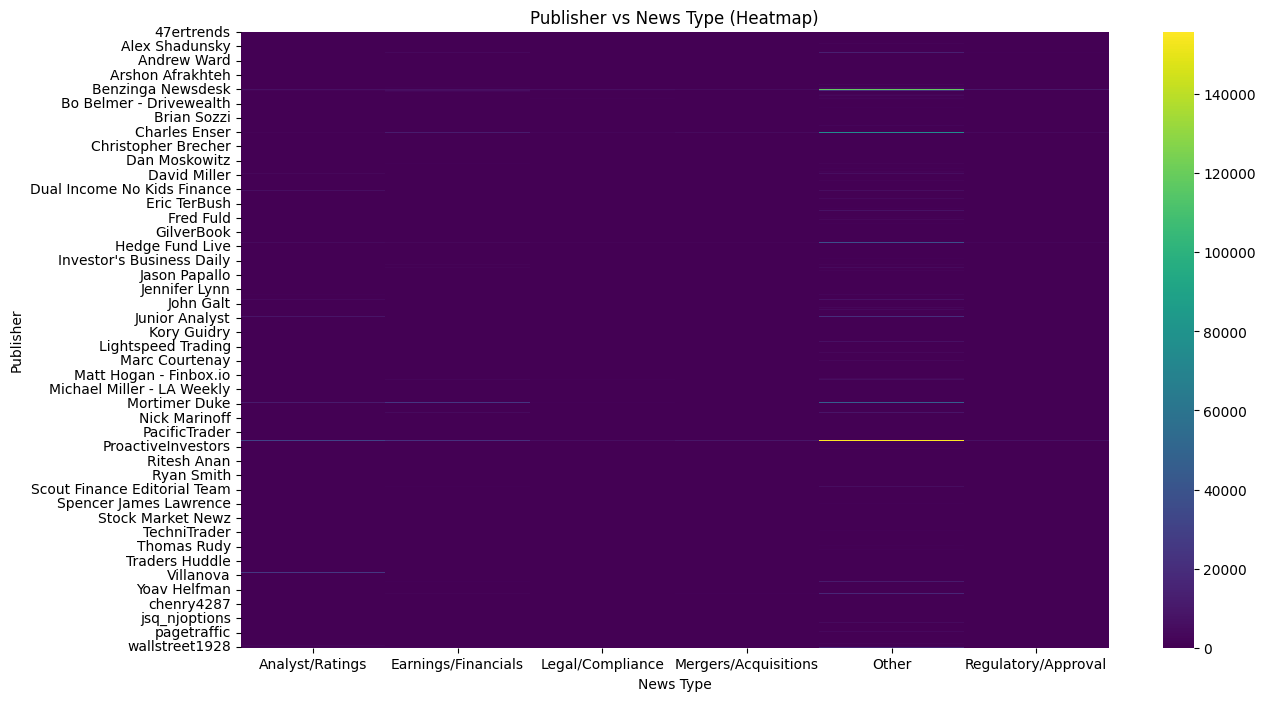

In [182]:
plt.figure(figsize=(14,8))
sns.heatmap(publisher_news_type, cmap="viridis")
plt.title("Publisher vs News Type (Heatmap)")
plt.xlabel("News Type")
plt.ylabel("Publisher")
plt.show()


In [183]:
from collections import Counter

def top_keywords_for_publisher(name, n=20):
    texts = df[df['publisher'] == name]['clean_headline'].tolist()
    words = " ".join(texts).split()
    return Counter(words).most_common(n)

top_keywords_for_publisher('wallstreet1928')  # example


[('ftse', 3),
 ('daily', 3),
 ('level', 2),
 ('analysis', 2),
 ('market', 2),
 ('strategy', 1),
 ('key', 1),
 ('sep', 1),
 ('october', 1),
 ('non', 1),
 ('farm', 1),
 ('payrolls', 1),
 ('arguments', 1),
 ('good', 1),
 ('number', 1),
 ('international', 1),
 ('round', 1),
 ('bulls', 1),
 ('bears', 1),
 ('drop', 1)]

### 4. Email-Based Publisher Domain Analysis

In [184]:
def get_domain(publisher):
    if '@' in publisher:
        return publisher.split('@')[-1].lower()
    return publisher.lower()

df['publisher_domain'] = df['publisher'].astype(str).apply(get_domain)


In [185]:
domain_counts = df['publisher_domain'].value_counts()
domain_counts.head(20)


publisher_domain
paul quintaro        228373
lisa levin           186979
benzinga newsdesk    150484
charles gross         96732
monica gerson         82380
eddie staley          57254
hal lindon            49047
etf professor         28489
juan lopez            28438
benzinga staff        28114
vick meyer            24826
webmaster             20313
benzinga_newsdesk     19410
zacks                 19390
jayson derrick        19050
allie wickman         18317
shanthi rexaline      16640
craig jones           16221
wayne duggan          12897
nelson hem            12590
Name: count, dtype: int64

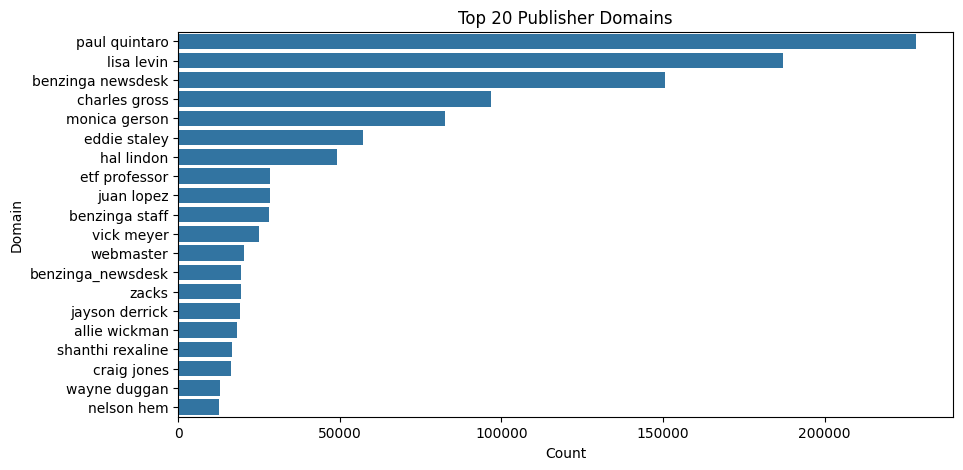

In [186]:
plt.figure(figsize=(10,5))
sns.barplot(x=domain_counts.head(20).values, y=domain_counts.head(20).index)
plt.title("Top 20 Publisher Domains")
plt.xlabel("Count")
plt.ylabel("Domain")
plt.show()


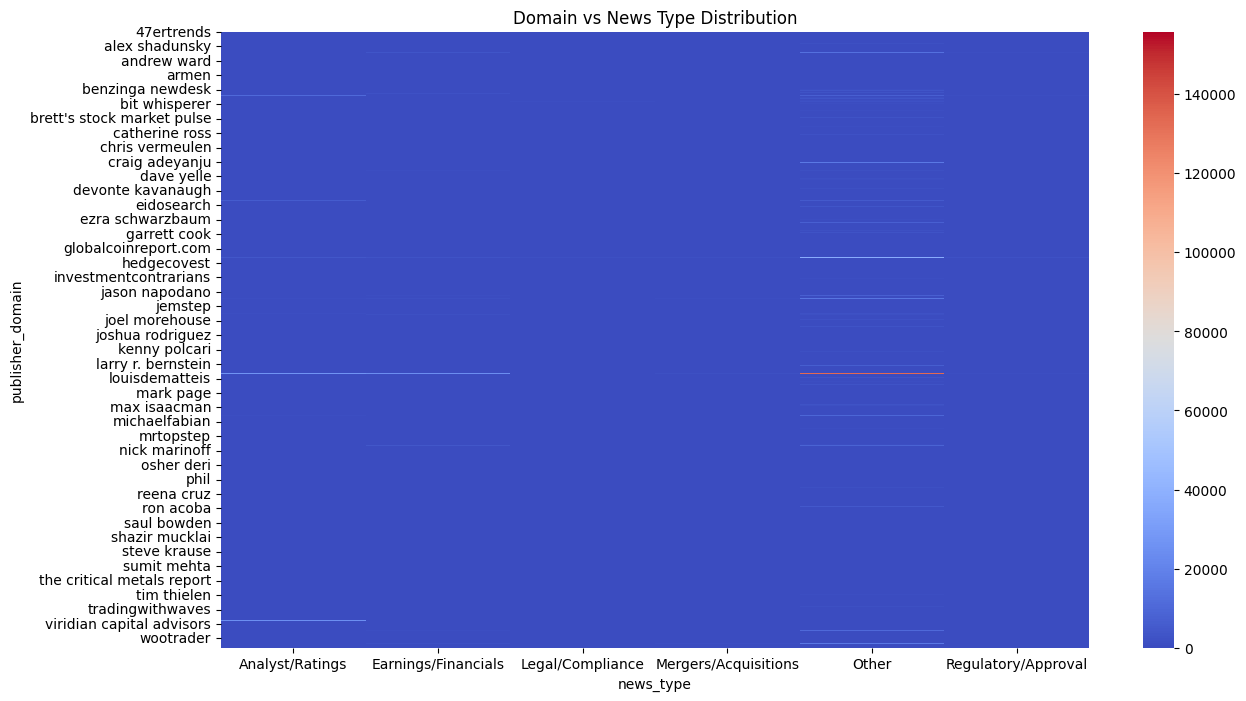

In [187]:
domain_news_type = df.groupby(['publisher_domain', 'news_type']).size().unstack(fill_value=0)

plt.figure(figsize=(14,8))
sns.heatmap(domain_news_type, cmap="coolwarm")
plt.title("Domain vs News Type Distribution")
plt.show()


# Task-2

In [188]:
import pandas as pd

# Define the specific stock symbols you want
target_stocks = ['AAPL', 'GOOG', 'META', 'NVDA', 'MSFT', 'AMZN']

# Load all the CSV files into a dictionary
stock_data = {}

for symbol in target_stocks:
    file_path = f'../data/{symbol}.csv'
    df = pd.read_csv(file_path, parse_dates=['Date'])
    df.set_index('Date', inplace=True)
    stock_data[symbol] = df
    print(f"Loaded {symbol} successfully")

print("\nLoaded stocks:", list(stock_data.keys()))

Loaded AAPL successfully
Loaded GOOG successfully
Loaded META successfully
Loaded NVDA successfully
Loaded MSFT successfully
Loaded AMZN successfully

Loaded stocks: ['AAPL', 'GOOG', 'META', 'NVDA', 'MSFT', 'AMZN']


In [189]:
required_cols = ['Close', 'High', 'Low', 'Open', 'Volume']

for symbol, df in stock_data.items():
    # keep only required columns
    df = df[required_cols]
    
    # reorder columns (optional)
    df = df[['Close', 'High', 'Low', 'Open', 'Volume']]
    
    stock_data[symbol] = df


In [190]:
combined = pd.concat(
    {symbol: df[['Close', 'High', 'Low', 'Open', 'Volume']] 
     for symbol, df in stock_data.items()},
    axis=1
)

combined.head()


AAPL                                                GOOG  \
               Close      High       Low      Open      Volume     Close   
Date                                                                       
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200  7.948608   
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400  8.115089   
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400  8.263762   
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800  7.965677   
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800  8.044340   

                                                     ...       MSFT  \
                High       Low      Open     Volume  ...      Close   
Date                                                 ...              
2009-01-02  7.960977  7.557264  7.633949  144961322  ...  14.872976   
2009-01-05  8.194003  7.792268  7.940692  196293007  ...  15.011971   
2009-01-06  8.430492  8.074027  8.237046  257971329  ...  15.187551   
2009-01-07  8.185839  7.885034  8.121770  180453860  ...  14.273087   
2009-01-08  8.044340  7.850152  7.873406  144567852  ...  14.719351   

                                                        AMZN                  \
                 High        Low       Open    Volume  Close    High     Low   
Date                                                                           
2009-01-02  14.924187  14.170662  14.287715  50084000  2.718  2.7265  2.5535   
2009-01-05  15.121707  14.675444  14.777866  61475200  2.703  2.7870  2.6515   
2009-01-06  15.363130  15.077815  15.180236  58083400  2.868  2.9110  2.6875   
2009-01-07  14.843718  14.251139  14.770560  72709900  2.810  2.8475  2.7675   
2009-01-08  14.770561  14.302350  14.360876  70255400  2.858  2.8660  2.7290   

                               
              Open     Volume  
Date                           
2009-01-02  2.5675  145928000  
2009-01-05  2.7865  190196000  
2009-01-06  2.7275  221602000  
2009-01-07  2.8145  158854000  
2009-01-08  2.7495  131558000  

[5 rows x 30 columns]

## Apply Analysis Indicators with TA-Lib 

In [191]:
import talib

for symbol, df in stock_data.items():

    # Simple Moving Averages
    df["SMA_20"] = talib.SMA(df["Close"], timeperiod=20)
    df["SMA_50"] = talib.SMA(df["Close"], timeperiod=50)

    # Exponential Moving Averages
    df["EMA_20"] = talib.EMA(df["Close"], timeperiod=20)
    df["EMA_50"] = talib.EMA(df["Close"], timeperiod=50)

    # RSI (Relative Strength Index)
    df["RSI_14"] = talib.RSI(df["Close"], timeperiod=14)

    # MACD (Moving Average Convergence Divergence)
    df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(
        df["Close"],
        fastperiod=12,
        slowperiod=26,
        signalperiod=9
    )

    print(f"Technical indicators added for {symbol}")


Technical indicators added for AAPL
Technical indicators added for GOOG
Technical indicators added for META
Technical indicators added for NVDA
Technical indicators added for MSFT
Technical indicators added for AMZN


In [192]:
stock_data["AAPL"].tail()


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,,,
2023-12-22,191.788757,193.581821,191.164647,193.353962,37149600,191.856618,183.572859,191.510231,186.389576,54.672784,2.633141,3.235256,-0.602115
2023-12-26,191.243912,192.076049,191.025969,191.798670,28919300,192.018094,183.858864,191.484867,186.579942,53.090049,2.304751,3.049155,-0.744404
2023-12-27,191.342972,191.689703,189.302247,190.689158,48087700,192.154308,184.149424,191.471353,186.766728,53.354446,2.029104,2.845145,-0.816041
2023-12-28,191.768951,192.838849,191.362784,192.323710,34049900,192.362839,184.479567,191.499696,186.962893,54.540999,1.823998,2.640915,-0.816918
2023-12-29,190.728775,192.581275,189.936256,192.085953,42672100,192.490633,184.814828,191.426275,187.110575,51.121347,1.559539,2.424640,-0.865101


In [193]:
stock_data["GOOG"].tail()


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,,,
2023-12-22,141.750000,142.276397,141.089511,141.164014,18513500,135.009596,133.914786,135.854576,134.406983,64.953309,1.412015,0.572046,0.839969
2023-12-26,141.849304,142.966658,141.531472,142.008205,11170100,135.246477,133.999010,136.425503,134.698839,65.115870,1.706565,0.798950,0.907615
2023-12-27,140.478683,142.345911,140.092320,141.859236,17288400,135.386520,134.017881,136.811520,134.925499,60.916026,1.808553,1.000870,0.807682
2023-12-28,140.319748,141.303025,139.870824,140.885881,12192500,135.628861,134.023641,137.145637,135.137038,60.429303,1.855168,1.171730,0.683438
2023-12-29,139.972137,140.473710,138.949139,139.723837,14881000,135.976979,134.056417,137.414827,135.326650,59.313063,1.842820,1.305948,0.536872


In [194]:
stock_data["META"].tail()

,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,,,
2023-12-22,351.224823,355.011477,349.068105,353.401377,11772800,332.302945,323.317843,335.581703,325.429670,67.333885,6.945367,4.729907,2.215461
2023-12-26,352.655975,354.792827,351.284456,352.814999,9898600,333.303278,324.115724,337.207824,326.497368,68.187000,7.436800,5.271285,2.165514
2023-12-27,355.637543,356.800387,353.132994,353.888347,13207900,334.239505,324.844828,338.963036,327.640120,69.947874,7.974921,5.812012,2.162908
2023-12-28,356.124634,359.682686,355.617749,357.496184,11798800,335.537503,325.527023,340.597473,328.757160,70.237702,8.344500,6.318510,2.025990
2023-12-29,351.791290,357.794292,349.664418,356.790470,14987100,336.869788,326.262290,341.663551,329.660459,64.296803,8.193282,6.693464,1.499818


In [195]:
stock_data["NVDA"].tail()

,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,,,
2023-12-22,48.805527,49.358247,48.442706,49.170342,252507000,47.706983,46.257777,48.024644,46.859635,55.352119,0.634352,0.564438,0.069914
2023-12-26,49.254299,49.575137,48.935459,48.943454,244200000,47.759019,46.334178,48.141754,46.953543,57.245971,0.655689,0.582688,0.073001
2023-12-27,49.392231,49.655100,49.060397,49.486186,233648000,47.838989,46.400666,48.260847,47.049178,57.837928,0.675937,0.601338,0.074599
2023-12-28,49.497185,49.859003,49.387239,49.618126,246587000,47.908266,46.512367,48.378593,47.145178,58.310919,0.692470,0.619564,0.072906
2023-12-29,49.497185,49.971949,48.726571,49.788039,389293000,48.046003,46.658888,48.485126,47.237414,58.310919,0.697532,0.635158,0.062374


In [196]:
stock_data["MSFT"].tail()

,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,,,
2023-12-22,369.767883,370.360181,367.921911,368.879451,17107500,368.730389,355.078464,366.580145,356.759327,56.363342,2.805416,3.840081,-1.034664
2023-12-26,369.846832,372.097540,368.701731,370.182461,12673100,368.535426,356.018111,366.891259,357.272563,56.447998,2.767033,3.625471,-0.858438
2023-12-27,369.264465,370.241738,368.020642,368.889342,14905400,368.109468,356.849368,367.117278,357.742833,55.591261,2.658971,3.432171,-0.773200
2023-12-28,370.458862,371.623696,369.353256,370.547702,14327000,367.933260,357.715942,367.435524,358.241501,57.031664,2.639285,3.273594,-0.634309
2023-12-29,371.209198,372.314805,368.682088,371.169703,18730800,367.791606,358.635943,367.794922,358.750038,57.954296,2.653640,3.149603,-0.495963


In [197]:
stock_data["AMZN"].tail()

,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,,,
2023-12-22,153.419998,154.350006,152.710007,153.770004,29514100,148.578999,141.2430,148.860492,143.528584,64.115558,3.135958,2.873052,0.262905
2023-12-26,153.410004,153.979996,153.029999,153.559998,25067200,148.863000,141.7154,149.293779,143.916091,64.085644,3.118650,2.922172,0.196478
2023-12-27,153.339996,154.779999,153.119995,153.559998,31434700,149.178500,142.1312,149.679133,144.285656,63.860893,3.063965,2.950530,0.113434
2023-12-28,153.380005,154.080002,152.949997,153.720001,27057000,149.531499,142.5694,150.031597,144.642297,63.938728,2.989395,2.958303,0.031092
2023-12-29,151.940002,153.889999,151.029999,153.100006,39823200,149.824000,143.0456,150.213350,144.928482,59.012257,2.782032,2.923049,-0.141017


##  PyNance for Financial Metrics

In [6]:
import pynance as pn
import numpy as np



Combined Data:
                AAPL  META      GOOG      NVDA       MSFT
Date                                                     
2009-01-02  2.721686   NaN  7.948608  0.199652  14.872976
2009-01-05  2.836553   NaN  8.115089  0.203319  15.011971
2009-01-06  2.789767   NaN  8.263762  0.210196  15.187551
2009-01-07  2.729484   NaN  7.965677  0.197589  14.273087
2009-01-08  2.780169   NaN  8.044340  0.192546  14.719351

Daily Returns:
                AAPL      META      GOOG      NVDA      MSFT
Date                                                        
2012-05-21  0.058260 -0.109861  0.022835  0.017384  0.016399
2012-05-22 -0.007679 -0.089039 -0.021674 -0.012205  0.000336
2012-05-23  0.024399  0.032258  0.014414  0.024711 -0.021841
2012-05-24 -0.009184  0.032187 -0.009516 -0.026527 -0.001375
2012-05-25 -0.005360 -0.033909 -0.020094  0.023947 -0.000344

Volatility:
AAPL    0.017896
META    0.025280
GOOG    0.017112
NVDA    0.027820
MSFT    0.016751
dtype: float64

Correlation Matrix:
 

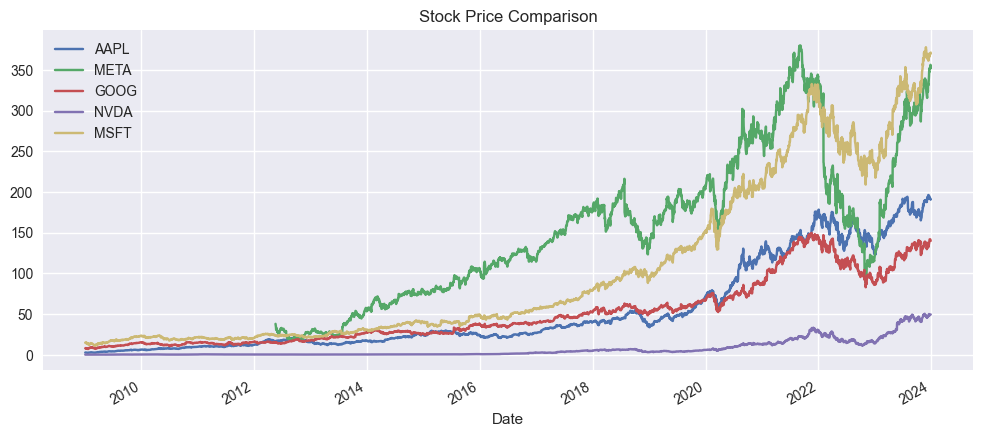

In [25]:
import pandas as pd
import numpy as np
import pynance as pn
import matplotlib.pyplot as plt

# Path to your folder
path = "../data/"

# Correct filenames
files = ["AAPL.csv", "META.csv", "GOOG.csv", "NVDA.csv","MSFT.csv"]

# Empty dict to store each stock
stock_data = {}

# Load all CSV files
for file in files:
    name = file.replace(".csv", "")  # AAPL, META, GOOG, NVDA
    
    df = pd.read_csv(path + file, parse_dates=['Date'], index_col='Date')
    
    # Store only the Close column
    stock_data[name] = df['Close']

# Combine all into one DataFrame
combined = pd.concat(stock_data, axis=1)

print("\nCombined Data:")
print(combined.head())

# ------------------------------------------
# Daily Returns
# ------------------------------------------
returns = combined.pct_change().dropna()
print("\nDaily Returns:")
print(returns.head())

# ------------------------------------------
# Moving Averages (20-day)
# ------------------------------------------
ma20 = combined.rolling(20).mean()

# ------------------------------------------
# Volatility
# ------------------------------------------
volatility = returns.std()
print("\nVolatility:")
print(volatility)

# ------------------------------------------
# Correlation Matrix
# ------------------------------------------
correlation = returns.corr()
print("\nCorrelation Matrix:")
print(correlation)

# ------------------------------------------
# Plot Price Chart
# ------------------------------------------
combined.plot(figsize=(12,5))
plt.title("Stock Price Comparison")
plt.show()

# ------------------------------------------
# PyNance Metrics (CAGR, Sharpe, etc.)
# ------------------------------------------

